# 🔭 PANOSETI Run Preview

This notebook provides a convenience interface to preview the latest data products and configurations from a PANOSETI observing run.

In [3]:
!uv add --active seaborn matplotlib anywidget>=0.9.0 plotly

Resolved 127 packages in 2ms
Checked 115 packages in 0.87ms


In [4]:
%matplotlib inline
import os
import glob
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from pypff import PanosetiRun, PFFSequence, hkpff
from rich import print as rprint
from tqdm.notebook import tqdm

# --- Configuration ---
DATA_DIR = "/mnt/panoseti-test"  # Base directory containing .pffd runs
# -----------------------

## 1. Discover Latest Run

Automatically finding the most recent `.pffd` directory in the configured data path.

In [33]:
def get_nth_latest_run(base_dir, n):
    runs = sorted(glob.glob(os.path.join(base_dir, "*.pffd")))
    if not runs:
        return None
    return Path(runs[-n])

n = 1
latest_run_path = get_nth_latest_run(DATA_DIR, n)

if latest_run_path:
    print(f"✅ Latest Run Found: {latest_run_path.name}")
    run = PanosetiRun(latest_run_path)
    run.show(details=False)
else:
    print(f"❌ No runs found in {DATA_DIR}")

✅ Latest Run Found: obs_sw-hw-gh-ucb.start_2026-05-12T02:51:29Z.runtype_hw-sw-eng.pffd


Run: obs_sw-hw-gh-ucb.start_2026-05-12T02:51:29Z.runtype_hw-sw-eng.pffd
├── Configurations & Metadata
│   ├── daq_config.json
│   ├── data_config.json
│   ├── meta.json
│   ├── network_config.json
│   ├── obs_config.json
│   ├── quabo_config_192.168.3.248.json
│   ├── quabo_config_192.168.3.249.json
│   ├── quabo_config_192.168.3.250.json
│   ├── quabo_config_192.168.3.251.json
│   ├── quabo_ph_baseline.json
│   ├── quabo_uids.json
│   ├── sw_info.json
│   ├── hp_stderr_panoseti-mini.jsonl
│   └── hp_stdout_panoseti-mini.jsonl
├── Logs
│   ├── dp_manifest.node_192.168.0.228.algo_blake3.txt
│   ├── hp_stderr_panoseti-mini.log
│   ├── hp_stdout_panoseti-mini.log
│   └── pss_192.168.0.228.log
├── Data Manifests
│   └── dp_manifest.node_192.168.0.228.algo_blake3.txt
├── Data Products
│   └── dp_ph256.bpp_2.module_254 (3,155 frames)
└── Housekeeping: hk.pff (69484 bytes)

## 1b. Configuration Viewer

Inspect run configurations with Rich formatting.

In [34]:
if 'run' in locals():
    config_select = widgets.Dropdown(
        options=sorted(run.configs.keys()),
        description='Config:',
        layout=widgets.Layout(width='400px')
    )
    
    config_out = widgets.Output()
    
    def show_config(change=None):
        with config_out:
            clear_output(wait=True)
            cfg = run.configs[config_select.value]
            if hasattr(cfg, 'model_dump'):
                rprint(cfg.model_dump())
            else:
                rprint(cfg)
                
    config_select.observe(show_config, names='value')
    show_config()
    display(widgets.VBox([config_select, config_out]))

## 2. Time-Multiplexed Interleaving Analysis

Analyze the collection rate and scheduling of all discovered data products.

Scanning Timestamps:   0%|          | 0/1 [00:00<?, ?it/s]

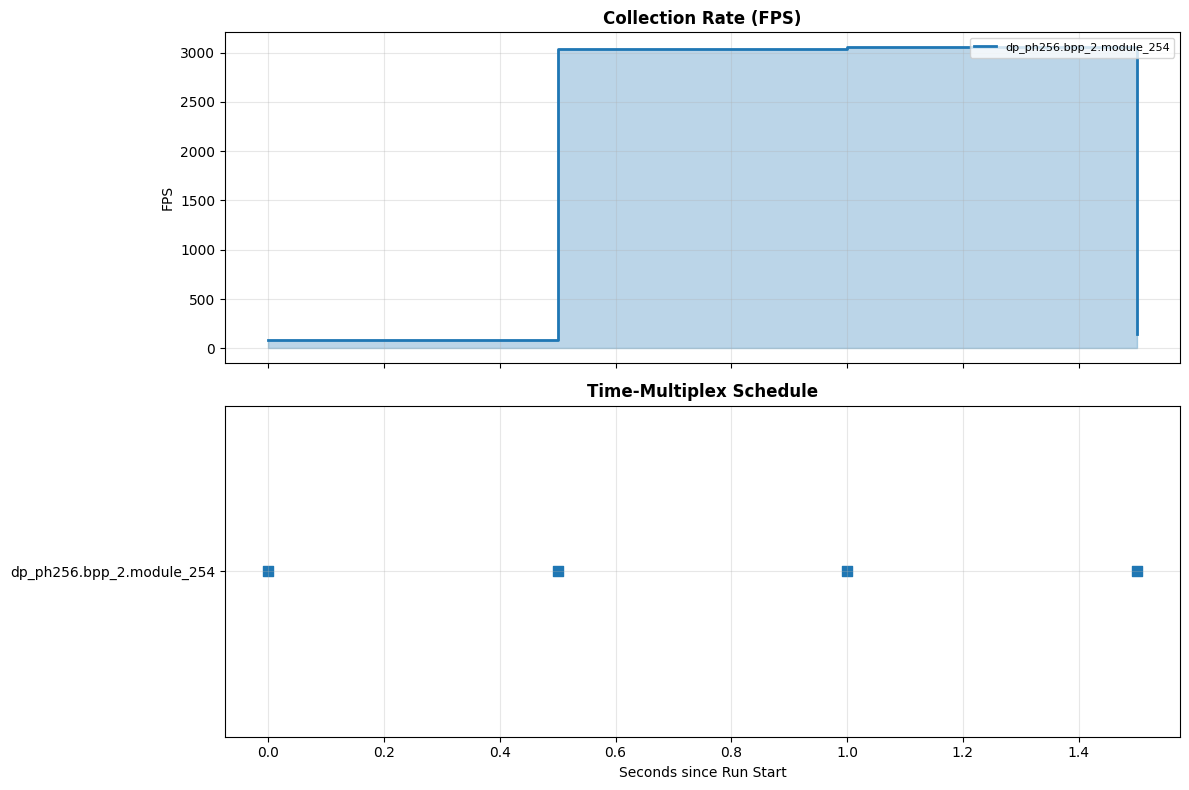

In [35]:
def extract_timeline(run_obj, sample_rate=1000, precise=True):
    data = {}
    for prod_name in tqdm(run_obj.list_products(), desc="Scanning Timestamps"):
        seq = run_obj.get_product(prod_name)
        if len(seq) == 0: continue
        
        indices = list(range(0, len(seq), sample_rate))
        if indices[-1] != len(seq) - 1: indices.append(len(seq) - 1)
        
        times = np.array([seq.get_frame_time(i, precise=precise) / 1e9 for i in indices])
        data[prod_name] = {"times": times, "indices": np.array(indices)}
    return data

if 'run' in locals():
    sample_rate = 1
    timeline = extract_timeline(run, sample_rate)

    if timeline:
        t0 = min([d["times"].min() for d in timeline.values()])
        max_t = max([d["times"].max() for d in timeline.values()]) - t0
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        bin_size = 0.5
        bins = np.arange(0, max_t + bin_size, bin_size)
        colors = plt.cm.tab10.colors
        
        for i, (name, d) in enumerate(timeline.items()):
            norm_times = d["times"] - t0
            counts, _ = np.histogram(norm_times, bins=bins)
            fps = (counts / bin_size) * sample_rate
            color = colors[i % len(colors)]
            
            ax1.step(bins[:-1], fps, where='post', label=name, color=color, linewidth=2)
            ax1.fill_between(bins[:-1], fps, step='post', color=color, alpha=0.3)
            
            active_bins = bins[:-1][fps > 0]
            ax2.scatter(active_bins, [name] * len(active_bins), marker='s', s=50, color=color)

        ax1.set_title('Collection Rate (FPS)', fontweight='bold')
        ax1.set_ylabel('FPS')
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper right', fontsize=8)
        
        ax2.set_title('Time-Multiplex Schedule', fontweight='bold')
        ax2.set_xlabel('Seconds since Run Start')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## 3. First N Frames Overview

Compact visualization of the start of each data product stream.

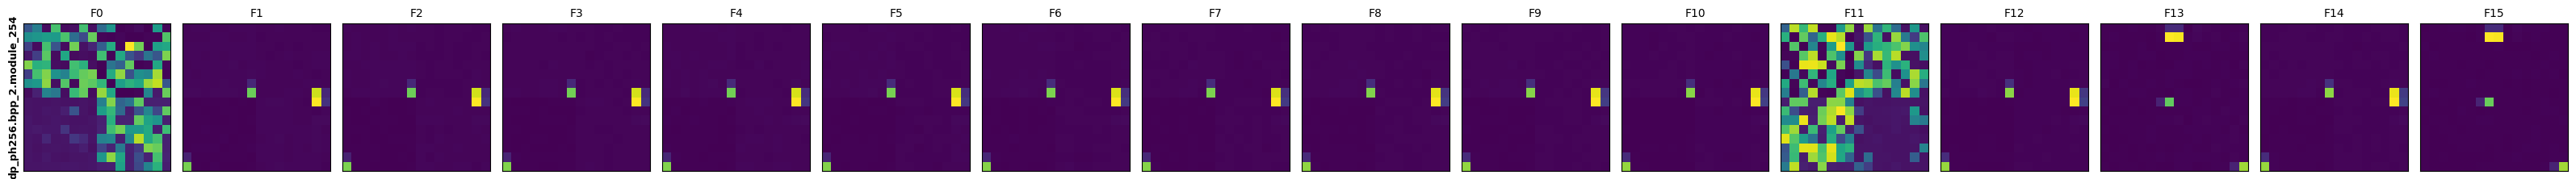

In [36]:
if 'run' in locals():
    n_samples = 16
    products = run.list_products()
    if products:
        fig, axes = plt.subplots(len(products), n_samples, figsize=(2 * n_samples, 2.5 * len(products)), squeeze=False)

        for row_idx, name in enumerate(products):
            seq = run.get_product(name)
            count = min(n_samples, len(seq))
            
            for col_idx in range(n_samples):
                ax = axes[row_idx, col_idx]
                if col_idx < count:
                    header, data = seq.get_frame(col_idx)
                    img_data = data.reshape(seq.frame_config.image_shape)
                    ax.imshow(img_data, cmap='viridis', origin='lower')
                    if col_idx == 0:
                        ax.set_ylabel(name, fontsize=9, fontweight='bold')
                else:
                    ax.axis('off')
                
                ax.set_xticks([])
                ax.set_yticks([])
                if row_idx == 0:
                    ax.set_title(f"F{col_idx}", fontsize=10)

        plt.tight_layout()
        plt.show()
    else:
        print("No products found to plot.")

## 3. Interactive Data Product Explorer

Browse through images and pulse-height data with precise timestamps.

In [18]:
if 'run' in locals():
    products = run.list_products()
    
    product_dropdown = widgets.Dropdown(
        options=products,
        description='Product:',
        layout=widgets.Layout(width='400px')
    )

    cmap_dropdown = widgets.Dropdown(
        options=['magma', 'viridis', 'plasma', 'inferno', 'gray', 'hot'],
        value='magma',
        description='Colormap:',
        layout=widgets.Layout(width='400px')
    )

    frame_slider = widgets.IntSlider(
        min=0,
        max=100,
        step=1,
        description='Frame:',
        continuous_update=False,
        layout=widgets.Layout(width='800px')
    )

    out = widgets.Output()

    def format_header(header):
        if hasattr(header, 'quabo_num'):
            return (
                f"Quabo {header.quabo_num} | Pkt: {header.pkt_num} | "
                f"TAI: {header.pkt_tai} | ns: {header.pkt_nsec}\n"
                f"UTC: {header.tv_sec}.{header.tv_usec:06d}"
            )
        elif hasattr(header, 'quabo_0'):
            return (
                f"Module Group | TAI (Q0): {header.quabo_0.pkt_tai} | ns: {header.quabo_0.pkt_nsec}\n"
                f"UTC: {header.quabo_0.tv_sec}.{header.quabo_0.tv_usec:06d}"
            )
        return str(header)

    def update_display(change=None):
        product_name = product_dropdown.value
        seq = run.get_product(product_name)
        frame_slider.max = len(seq) - 1
        
        frame_idx = min(frame_slider.value, len(seq) - 1)
        header, data = seq.get_frame(frame_idx)
        precise_time_ns = seq.get_frame_time(frame_idx, precise=True)
        
        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # Force 2D visualization for all products
            # Image shape is retrieved from sequence frame_config
            img_data = data.reshape(seq.frame_config.image_shape)
            
            im = ax.imshow(img_data, cmap=cmap_dropdown.value, origin='lower', interpolation='nearest')
            fig.colorbar(im, ax=ax, label='ADC Value')
            
            title = f"{product_name} [Frame {frame_idx}]\n{format_header(header)}\nPrecise: {precise_time_ns} ns"
            ax.set_title(title, loc='left', family='monospace', fontsize=10)
            plt.tight_layout()
            plt.show()

    product_dropdown.observe(update_display, names='value')
    cmap_dropdown.observe(update_display, names='value')
    frame_slider.observe(update_display, names='value')
    update_display()

    display(widgets.VBox([widgets.HBox([product_dropdown, cmap_dropdown]), frame_slider, out]))

## 5. HK Viewer

Read standard and JSONL logs directly from the run directory.

In [19]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

hk_data = run.get_hk()  # New memory-efficient lazy loader

# 1. Setup the FigureWidget
fig = go.FigureWidget()
# Initialize with a dummy trace so we have something to update
fig.add_trace(go.Scatter(y=[], mode='lines', name='Telemetry'))
fig.update_layout(
    template="plotly_white",
    height=450,
    hovermode="x unified",
    margin=dict(l=50, r=50, t=50, b=50),
    xaxis_title="Sample Index",
    yaxis_title="Value"
)

device_select = widgets.Select(options=sorted(hk_data.keys()), description='Device:')
param_select = widgets.Select(options=[], description='Param:')

def update_hk_plot(change=None):
    """Pushes new data to the existing FigureWidget."""
    device = device_select.value
    param = param_select.value
    
    if not device or not param:
        return
    
    # Grab the data
    values = hk_data[device][param]
    
    # Debug check: If you see nothing, it might be the data type.
    # We ensure it's a list or numpy array.
    if hasattr(values, 'tolist'): # Handle numpy/pandas
        plot_vals = values.tolist()
    else:
        plot_vals = list(values)

    with fig.batch_update():
        fig.data[0].y = plot_vals
        fig.data[0].name = param
        fig.layout.title.text = f"<b>{device}</b>: {param}"
        # Force the axis to rescale to the new data
        fig.layout.yaxis.autorange = True
        fig.layout.xaxis.autorange = True

def update_params(change=None):
    """Updates the parameter list when the device changes."""
    device = device_select.value
    if device:
        new_options = sorted(hk_data[device].keys())
        param_select.options = new_options
        if new_options:
            # Setting the value triggers the param_select observer
            param_select.value = new_options[0]
            # Explicitly call the plot update to be safe
            update_hk_plot()

# Setup Observers
device_select.observe(update_params, names='value')
param_select.observe(update_hk_plot, names='value')

# 2. Initial Run to populate everything
update_params()

# 3. Display
display(widgets.VBox([
    widgets.HBox([device_select, param_select]),
    fig
]))

## 6. Log File Viewer

Read standard and JSONL logs directly from the run directory.

In [20]:
if 'run' in locals():
    available_logs = run.list_logs() + list(run.metadata.keys())
    
    log_select = widgets.Dropdown(
        options=sorted(available_logs),
        description='Log File:',
        layout=widgets.Layout(width='500px')
    )
    
    log_out = widgets.Output()
    
    def show_log(change=None):
        name = log_select.value
        with log_out:
            clear_output(wait=True)
            if name in run.metadata:
                # JSONL metadata (parsed)
                rprint(run.metadata[name][:20]) # Show first 20 entries
                print(f"... [{len(run.metadata[name])} total entries]")
            else:
                # Standard text log
                print(run.get_log(name))
                
    log_select.observe(show_log, names='value')
    show_log()
    display(widgets.VBox([log_select, log_out]))

## 4. Advanced Performance Features

Leveraging the modernized `pypff` API for high-performance analysis, slicing, and temporal seeking.

In [ ]:
if 'run' in locals():
    prod_name = run.list_products()[0]
    seq = run.get_product(prod_name)
    
    # 1. High-Performance Slicing (returns NumPy array directly)
    # This is much faster than looping over get_frame for bulk data
    images = seq[0:100:2]  # Every 2nd frame from the first 100
    print(f"Slicing Result: {images.shape} {images.dtype}")
    
    # 2. Bulk Metadata Retrieval
    # get_all_metadata returns a structured dictionary of arrays
    metadata = seq.get_all_metadata()
    if 'quabo_0' in metadata:
        pkt_nums = metadata['quabo_0']['pkt_num']
    else:
        pkt_nums = metadata['pkt_num']
    print(f"Vectorized Metadata: {len(pkt_nums)} packet numbers indexed")
    
    # 3. Time-Based Seeking
    # Find a frame by its absolute timestamp (binary search)
    t_start = seq.get_frame_time(0)
    t_target = t_start + 1_000_000_000  # 1 second later
    
    idx = seq.seek_time(t_target)
    header, img = seq.get_frame(idx)
    print(f"Seek Result: Found frame {idx} at {seq.get_frame_time(idx)} ns")

## Experimental

In [8]:
import numpy as np
from numpy.lib.stride_tricks import as_strided

def view_as_chunks(arr, chunk_shape):
    """
    Creates a 5D view of a 3D (frames, H, W) array partitioned into non-overlapping chunks.
    """
    # Ensure the array is contiguous for predictable strides
    arr = np.ascontiguousarray(arr)
    
    nframes, h_orig, w_orig = arr.shape
    h_chunk, w_chunk = chunk_shape
    
    # Calculate dimensions of the grid of chunks
    n_h = h_orig // h_chunk
    n_w = w_orig // w_chunk
    
    # New shape: (grid_rows, grid_cols, chunk_height, chunk_width)
    new_shape = (nframes, n_h, n_w, h_chunk, w_chunk)
    
    # Calculate strides:
    # 1. Row of chunks: skip h_chunk * original_row_stride bytes
    # 2. Column of chunks: skip w_chunk * original_col_stride bytes
    # 3. Inside chunk row: original_row_stride
    # 4. Inside chunk col: original_col_stride
    s_f, s_h, s_w = arr.strides
    new_strides = (1, s_h * h_chunk, s_w * w_chunk, s_h, s_w)
    
    return as_strided(arr, shape=new_shape, strides=new_strides)


In [9]:
for prod_name in tqdm(run.list_products(), desc="Scanning Timestamps"):
    seq = run.get_product(prod_name)
    if 'ph256' in prod_name: 
        seq.get_metadata_arrays(['quabo_num'])
    else:
        data = seq.get_image_array(0)
        data_strided = view_as_chunks(data, (16,16))
        data_strided_max_per_quabo = np.max(data_strided, axis=(3,4))

Scanning Timestamps:   0%|          | 0/2 [00:00<?, ?it/s]

In [10]:
f = 1
r, c = 1, 0
np.max(data[f][r * 16:(r + 1) * 16, c * 16:(c + 1) * 16])

np.int16(1937)

In [11]:
data_strided_max_per_quabo[1]

array([[32512,  7424],
       [ 4608,  6400]], dtype=int16)

Scanning Timestamps:   0%|          | 0/2 [00:00<?, ?it/s]

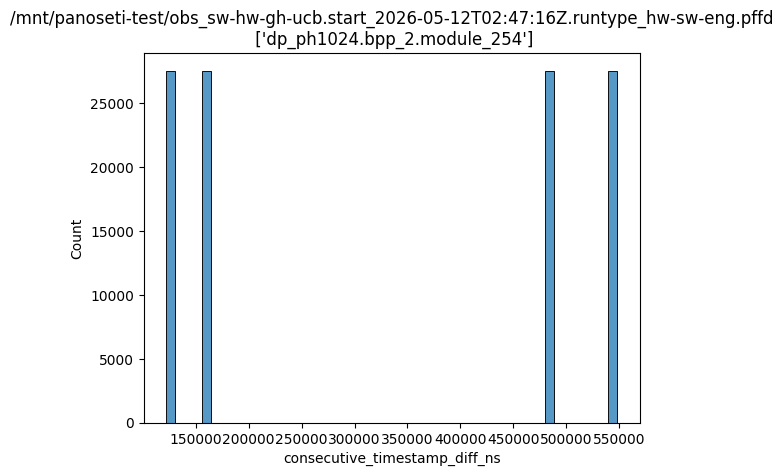

In [32]:
def extract_timeline_precise_ns(run_obj, sample_rate=100):
    data = {}
    for prod_name in tqdm(run_obj.list_products(), desc="Scanning Timestamps"):
        seq = run_obj.get_product(prod_name)
        if len(seq) == 0: continue
        
        indices = list(range(0, len(seq), sample_rate))
        if indices[-1] != len(seq) - 1: indices.append(len(seq) - 1)
        
        times = np.array([seq.get_frame_time(i, precise=True) for i in indices])
        data[prod_name] = {
            "unix_t_ns": times,
            "consecutive_timestamp_diff_ns": np.diff(times, prepend=times[0]),
            "indices": np.array(indices),
        }
    return data

def get_timeline_df(run, sample_rate=1):
    tl = extract_timeline_precise_ns(run, sample_rate=sample_rate)
    
    dfs = []
    for dp in tl:
        # rprint(f"{dp}: {tl[dp]}")
        # tl_deltas = tl[dp]['diff']
        # rprint(f"tl_deltas (µs): {tl_deltas / 1e3}")
        df = pd.DataFrame(tl[dp])
        df['dp'] = dp
        dfs.append(df)
    
    return pd.concat(dfs)
    

def plot_diff(timeline_df, dp_pats=[], q_min=0.025, q_max=0.975):
    import seaborn as sns
    patterns = '|'.join(dp_pats)
    if dp_pats:
        filtered_df = timeline_df[timeline_df['dp'].str.contains(patterns)]
    else:
        filtered_df = timeline_df
    q_low = filtered_df['consecutive_timestamp_diff_ns'].quantile(q_min)
    q_high = filtered_df['consecutive_timestamp_diff_ns'].quantile(q_max)
    filtered_df = filtered_df[filtered_df['consecutive_timestamp_diff_ns'].between(q_low, q_high)]
    sns.histplot(
        data=filtered_df,
        x='consecutive_timestamp_diff_ns',
        log_scale=False,
        stat='count',
        bins=50
    )
    plt.title(f"{run.run_dir}\n {list(filtered_df['dp'].unique())}")
    plt.locator_params(axis='x', nbins=10)

import pandas as pd

df_all = get_timeline_df(run)
# display(df_all)

plot_diff(df_all, dp_pats=['ph'])

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def get_quadrant_id(frame):
    """
    Identifies the quadrant (Q0-Q3) containing the peak intensity.
    Handles both 2D (H, W) and 3D (C, H, W) frames.
    Mapping: TL=Q0, TR=Q1, BR=Q2, BL=Q3 (Clockwise)
    """
    # 1. Find the multi-dimensional index of the max value
    max_idx = np.unravel_index(np.argmax(frame, axis=None), frame.shape)
    
    # 2. Extract row and col from the end of the tuple
    # This works regardless of whether max_idx is (r, c) or (0, r, c)
    row, col = max_idx[-2], max_idx[-1]
    
    # 3. Determine grid position (0 or 1) based on 16x16 quadrants
    q_row = row // 16
    q_col = col // 16
    
    # 4. Map to Clockwise Q0-Q3
    # (0,0)->Q0 [TL], (0,1)->Q1 [TR], (1,1)->Q2 [BR], (1,0)->Q3 [BL]
    mapping = {
        (0, 0): "Q0",
        (0, 1): "Q1",
        (1, 1): "Q2",
        (1, 0): "Q3"
    }
    return mapping.get((q_row, q_col), "Unknown")


def extract_timeline_optimized(run_obj, sample_rate=100):
    data = {}
    for prod_name in tqdm(run_obj.list_products(), desc="Optimizing Products"):
        seq = run_obj.get_product(prod_name)
        n_frames = len(seq)
        if n_frames == 0: continue
        
        # 1. Create indices
        indices = np.arange(0, n_frames, sample_rate)
        if indices[-1] != n_frames - 1:
            indices = np.append(indices, n_frames - 1)

        # 2. Optimized Timestamp Extraction
        # Now supporting direct index-based vectorized retrieval
        try:
            res = seq.get_metadata_arrays(['unix_t_ns'], indices=indices)
            times = res['unix_t_ns']
        except Exception:
            # Fallback if bulk metadata isn't supported
            times = np.array([seq.get_frame_time(int(i), precise=True) for i in indices])

            
        # FORCE 1D: Prevents Pandas from getting confused
        times = np.asarray(times).ravel()

        # 3. Robust Quadrant Analysis
        if 'ph256' in prod_name:
            q_nums = seq.get_metadata_arrays(['quabo_num'])['quabo_num'][indices]
            q_nums = np.asarray(q_nums).ravel()
            quadrants = [f"Q{int(q)}" for q in q_nums]
        else:
            # IMAGE PATH: Process on the fly to avoid shape mismatch errors
            quadrants = []
            q_labels = ["Q0", "Q1", "Q2", "Q3"]
            
            for i in indices:
                frame = seq.get_image_array(int(i))
                
                # The ellipsis (...) gracefully handles any leading dimensions (e.g. channel dims)
                # It calculates the max intensity for each 16x16 block directly
                try:
                    q0_max = frame[..., 0:16, 0:16].max()
                    q1_max = frame[..., 0:16, 16:32].max()
                    q2_max = frame[..., 16:32, 16:32].max()
                    q3_max = frame[..., 16:32, 0:16].max()
                    
                    winner_idx = np.argmax([q0_max, q1_max, q2_max, q3_max])
                    quadrants.append(q_labels[winner_idx])
                except ValueError:
                    # Failsafe for completely broken/empty frames that can't be sliced
                    quadrants.append("Unknown")

        # Defensive Programming: Guarantee all arrays match the exact minimum length 
        min_len = min(len(times), len(quadrants), len(indices))
        times = times[:min_len]
        indices = indices[:min_len]
        quadrants = quadrants[:min_len]
        
        # Calculate diff ONLY after lengths are guaranteed and flattened
        diffs = np.diff(times, prepend=times[0]) if len(times) > 0 else np.array([])

        data[prod_name] = {
            "unix_t_ns": times,
            "consecutive_timestamp_diff_ns": diffs,
            "indices": indices,
            "max_quabo": quadrants
        }
        
    return data


def get_timeline_df(run, sample_rate=1):
    tl = extract_timeline_optimized(run, sample_rate=sample_rate)
    
    dfs = []
    for dp in tl:
        # rprint(f"{dp}: {tl[dp]}")
        # tl_deltas = tl[dp]['diff']
        # rprint(f"tl_deltas (µs): {tl_deltas / 1e3}")
        df = pd.DataFrame(tl[dp])
        df['dp'] = dp
        dfs.append(df)
    
    return pd.concat(dfs)

def plot_diff(timeline_df, dp_pats=[], q_min=0.001, q_max=0.999):
    plt.figure(figsize=(12, 6))
    
    # Filter by product patterns
    patterns = '|'.join(dp_pats)
    if dp_pats:
        filtered_df = timeline_df[timeline_df['dp'].str.contains(patterns)].copy()
    else:
        filtered_df = timeline_df.copy()
        
    if filtered_df.empty:
        print("No data found for the given patterns.")
        return

    # Outlier removal (crucial for timing plots)
    q_low = filtered_df['consecutive_timestamp_diff_ns'].quantile(q_min)
    q_high = filtered_df['consecutive_timestamp_diff_ns'].quantile(q_max)
    plot_data = filtered_df[filtered_df['consecutive_timestamp_diff_ns'].between(q_low, q_high)]

    # Density plot with Quadrant Hue
    sns.histplot(
        data=plot_data,
        x='consecutive_timestamp_diff_ns',
        hue='max_quabo',
        hue_order=['Q0', 'Q1', 'Q2', 'Q3'], # Force clockwise order in legend
        palette='viridis',
        multiple='layer',
        element='step',
        stat='density',
        common_norm=False
    )
    
    plt.xlabel("Delta T (ns)")
    plt.title(f"Inter-frame Timing by Peak Quadrant\nProducts: {list(filtered_df['dp'].unique())}")
    plt.grid(True, alpha=0.3)
    plt.show()


# Execution
df_all = get_timeline_df(run, sample_rate=100) # Use sample_rate > 1 for speed on large PFFs
plot_diff(df_all, dp_pats=['img'])

Optimizing Products:   0%|          | 0/2 [00:00<?, ?it/s]

KeyboardInterrupt: 